# 04 · Ranking de oportunidad
**High Garden Coffee**

**Objetivo:** combinar el pronóstico (notebook 02) y la segmentación (notebook 03) en un ranking de mercados priorizados, y comprobar qué tan robusto es ese ranking a los pesos que se usen.

**Entradas:** `outputs/forecast.parquet`, `outputs/backtest.parquet`, `outputs/segments.parquet`, `outputs/coffee_long.parquet`
**Salidas:** `outputs/ranking.parquet` y `outputs/ranking.csv`

**Qué significa "oportunidad" aquí.** Los 55 países del dataset son productores, así que el ranking identifica **mercados domésticos cuya demanda de café crece más y con mayor certeza**. No es demanda de importación ni tiene en cuenta precios o márgenes (no hay datos de eso).

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

from utils import *

warnings.filterwarnings("ignore", category=DeprecationWarning)  # avisos de pandas por groupby.apply
sns.set_theme(style="whitegrid", context="notebook")
pd.options.display.float_format = "{:,.3f}".format

long = load_long()
universe = modelable_countries(long)
fc = pd.read_parquet(OUT / "forecast.parquet")
seg = pd.read_parquet(OUT / "segments.parquet").set_index("country")
bt = pd.read_parquet(OUT / "backtest.parquet")
print(f"{len(universe)} países · pronóstico {fc.season.iloc[0]} → {fc.season.iloc[-1]}")

51 países · pronóstico 2020/21 → 2024/25


## 1. Métricas por país
Para cada país se toma el pronóstico a 5 temporadas (2024/25) frente al último dato real (2019/20):

| Métrica | Definición |
|---|---|
| `crec_abs` | Volumen adicional proyectado (millones) |
| `cagr_proy` | Crecimiento anual proyectado |
| `crec_reciente` | Crecimiento anual observado en las últimas 5 temporadas |
| `err_backtest` | Error real del método en ese país: sMAPE mediano del backtest (notebook 02) |

In [2]:
last = long[long.year == 2019].set_index("country")["consumption_m"]
f5 = fc[fc.h == 5].set_index("country")

opp = pd.DataFrame(index=universe)
opp["segmento"] = seg["segmento"]
opp["grupo_serie"] = f5["group"]
opp["flat_share"] = f5["flat_share"]
opp["y19"] = last
opp["y24"] = f5["yhat"]
opp["lo"], opp["hi"] = f5["lo"], f5["hi"]
opp["crec_abs"] = opp.y24 - opp.y19
opp["cagr_proy"] = (opp.y24 / opp.y19) ** (1 / 5) - 1
opp["crec_reciente"] = np.exp(seg["trend_5"]) - 1
bh = bt[bt.model == "hybrid"]
opp["err_backtest"] = (bh.groupby(["country", "origin"]).apply(lambda g: smape(g.actual, g.pred))
                         .groupby("country").median())
opp.sort_values("crec_abs", ascending=False).head(10)[
    ["segmento", "y19", "y24", "crec_abs", "cagr_proy", "crec_reciente"]]

,segmento,y19,y24,crec_abs,cagr_proy,crec_reciente
Brazil,Grandes en crecimiento sostenido,"1,320.000","1,466.303",146.303,0.021,0.019
Vietnam,Emergentes de alto crecimiento,159.000,220.173,61.173,0.067,0.037
Indonesia,Grandes en crecimiento sostenido,288.360,347.963,59.603,0.038,0.014
Philippines,Emergentes de alto crecimiento,195.000,231.191,36.191,0.035,0.025
Ethiopia,Grandes en crecimiento sostenido,226.860,256.255,29.395,0.025,0.019
Thailand,Emergentes de alto crecimiento,84.000,107.358,23.358,0.050,0.019
Colombia,Grandes en crecimiento sostenido,121.486,142.330,20.844,0.032,0.036
Mexico,Grandes en crecimiento sostenido,145.500,153.932,8.432,0.011,0.012
India,Maduros estancados,87.000,90.810,3.810,0.009,0.002
Uganda,Grandes en crecimiento sostenido,15.240,17.929,2.689,0.033,0.021


## 2. Score de oportunidad
Cuatro dimensiones, cada una convertida a **percentil (0–1)** entre los 51 países para poder sumarlas sin que una escala domine:

| Dimensión | Métrica | Peso base | Por qué |
|---|---|---|---|
| Escala | `crec_abs` (en escala log) | 35% | Cuánto volumen nuevo aparece: lo que más mueve el negocio |
| Dinamismo | `cagr_proy` | 20% | Velocidad de crecimiento proyectada |
| Momentum | `crec_reciente` | 25% | Evita premiar países cuya historia larga fue buena pero hoy se desaceleran |
| Confianza | inverso de `err_backtest` | 20% | Países donde el método ha acertado más en el pasado = menos riesgo |

**Por qué la escala va en log y no en percentil.** Con percentiles, +0.1 M de un país diminuto puntúa casi igual que +8 M, porque 20 países tienen crecimiento exactamente 0 y el resto queda "por encima". En escala logarítmica cada orden de magnitud cuenta lo mismo (+0.1 M, +1 M, +10 M, +100 M), y Brasil no aplasta al resto. El valor se lleva a 0–1 con min–max; las caídas cuentan como 0.

**Por qué la confianza usa el error de backtest y no el intervalo.** Los intervalos del notebook 02 se calibran por tipo de serie y son multiplicativos, así que todos los países "dinámicos" tienen exactamente el mismo ancho relativo: no sirven para distinguirlos. El error histórico de backtest, en cambio, es propio de cada país.

**Regla para series planas:** su error de backtest es casi cero porque la serie es constante (probablemente estimada), no porque el futuro sea predecible. Por eso reciben **0 en Confianza**: no se les acredita certeza que el dato no puede sostener.

In [3]:
DIMS = ["d_escala", "d_dinamismo", "d_momentum", "d_confianza"]
W_BASE = np.array([0.35, 0.20, 0.25, 0.20])

esc = np.log1p(opp.crec_abs.clip(lower=0))
opp["d_escala"] = (esc - esc.min()) / (esc.max() - esc.min())
opp["d_dinamismo"] = opp.cagr_proy.rank(pct=True)
opp["d_momentum"] = opp.crec_reciente.rank(pct=True)

dinamica = opp.grupo_serie == "dinámica"
opp["d_confianza"] = 0.0
opp.loc[dinamica, "d_confianza"] = (-opp.loc[dinamica, "err_backtest"]).rank(pct=True)

opp["score"] = opp[DIMS].values @ W_BASE * 100
opp["ranking"] = opp.score.rank(ascending=False, method="min").astype(int)
opp.sort_values("ranking").head(12)[["segmento", "score"] + DIMS]

,segmento,score,d_escala,d_dinamismo,d_momentum,d_confianza
Brazil,Grandes en crecimiento sostenido,84.668,1.000,0.784,0.843,0.645
Ethiopia,Grandes en crecimiento sostenido,78.667,0.684,0.804,0.824,0.903
Vietnam,Emergentes de alto crecimiento,78.624,0.827,1.000,0.980,0.258
Indonesia,Grandes en crecimiento sostenido,78.173,0.822,0.941,0.784,0.548
Philippines,Emergentes de alto crecimiento,77.944,0.724,0.922,0.902,0.581
Colombia,Grandes en crecimiento sostenido,71.282,0.618,0.863,0.961,0.419
Thailand,Emergentes de alto crecimiento,65.568,0.640,0.961,0.804,0.194
Mexico,Grandes en crecimiento sostenido,62.026,0.450,0.706,0.745,0.677
Bolivia,Grandes en crecimiento sostenido,61.068,0.081,0.824,0.922,0.935
Uganda,Grandes en crecimiento sostenido,59.082,0.261,0.902,0.863,0.516


## 3. ¿Qué tan robusto es el ranking a los pesos?
Los pesos son una decisión de negocio, no un dato. En vez de defender unos pesos concretos, se **simulan 5,000 combinaciones aleatorias de pesos** y se mide con qué frecuencia cada país queda en el top 10. Un país que está arriba con casi cualquier ponderación es una apuesta robusta; uno que depende de los pesos, no.

In [4]:
rng = np.random.default_rng(42)
Ws = rng.dirichlet(np.ones(len(DIMS)), size=5000)          # (5000, 4), cada fila suma 1
S = opp[DIMS].values @ Ws.T                                 # (51, 5000)
R = (-S).argsort(axis=0).argsort(axis=0) + 1                # ranking 1 = mejor

opp["freq_top10"] = (R <= 10).mean(axis=1)
opp["rank_mediano"] = np.median(R, axis=1)
opp["rank_p10"] = np.percentile(R, 10, axis=1)
opp["rank_p90"] = np.percentile(R, 90, axis=1)

rho = spearmanr(opp.ranking, opp.rank_mediano).statistic
print(f"Correlación (Spearman) entre el ranking base y el ranking mediano de las simulaciones: {rho:.2f}")

opp["cuota_2019"] = opp.y19 / opp.y19.sum()


def nivel(r):
    if r.freq_top10 >= 0.70:
        return "Prioritario" if r.cuota_2019 >= 0.01 else "Nicho prometedor"
    if r.freq_top10 >= 0.30:
        return "Candidato"
    return "Bajo"


opp["nivel"] = opp.apply(nivel, axis=1)

# Alerta: el modelo proyecta crecer >3 pp por año más rápido que el ritmo reciente (y hay crecimiento real)
opp["alerta_optimismo"] = ((opp.cagr_proy - opp.crec_reciente) > 0.03) & (opp.cagr_proy > 0.01)
print(opp.nivel.value_counts().to_string())

Correlación (Spearman) entre el ranking base y el ranking mediano de las simulaciones: 1.00
nivel
Bajo                40
Prioritario          7
Nicho prometedor     2
Candidato            2


**Niveles.**
- *Prioritario*: top 10 en ≥ 70% de los escenarios de pesos **y** al menos 1% del consumo total.
- *Nicho prometedor*: igual de robusto, pero con menos de 1% del consumo. Tres de las cuatro dimensiones miden tasas (no tamaño), así que los mercados chicos con crecimiento parejo suben en el ranking; esta categoría los deja visibles sin mezclarlos con los mercados que realmente mueven volumen. (El umbral de 1% se añadió tras ver este efecto en los primeros resultados.)
- *Candidato*: top 10 entre 30% y 70% de los escenarios.
- *Bajo*: menos de 30%.

## 4. Resultado

In [5]:
ranking = opp.sort_values("score", ascending=False).assign(posicion=lambda d: range(1, len(d) + 1))
cols = ["posicion", "segmento", "nivel", "score", "freq_top10", "rank_p10", "rank_p90",
        "cuota_2019", "y19", "y24", "crec_abs", "cagr_proy", "crec_reciente", "alerta_optimismo", "grupo_serie"]
ranking[cols].head(15)

,posicion,segmento,nivel,score,freq_top10,rank_p10,rank_p90,cuota_2019,y19,y24,crec_abs,cagr_proy,crec_reciente,alerta_optimismo,grupo_serie
Brazil,1,Grandes en crecimiento sostenido,Prioritario,84.668,0.991,1.000,7.000,0.440,"1,320.000","1,466.303",146.303,0.021,0.019,False,dinámica
Ethiopia,2,Grandes en crecimiento sostenido,Prioritario,78.667,1.000,1.000,7.000,0.076,226.860,256.255,29.395,0.025,0.019,False,dinámica
Vietnam,3,Emergentes de alto crecimiento,Prioritario,78.624,0.854,1.000,15.000,0.053,159.000,220.173,61.173,0.067,0.037,True,dinámica
Indonesia,4,Grandes en crecimiento sostenido,Prioritario,78.173,0.959,2.000,8.000,0.096,288.360,347.963,59.603,0.038,0.014,False,dinámica
Philippines,5,Emergentes de alto crecimiento,Prioritario,77.944,0.977,2.000,5.000,0.065,195.000,231.191,36.191,0.035,0.025,False,dinámica
Colombia,6,Grandes en crecimiento sostenido,Prioritario,71.282,0.872,4.000,12.100,0.041,121.486,142.330,20.844,0.032,0.036,False,dinámica
Thailand,7,Emergentes de alto crecimiento,Candidato,65.568,0.632,6.000,20.000,0.028,84.000,107.358,23.358,0.050,0.019,True,dinámica
Mexico,8,Grandes en crecimiento sostenido,Prioritario,62.026,0.733,7.000,12.000,0.049,145.500,153.932,8.432,0.011,0.012,False,dinámica
Bolivia,9,Grandes en crecimiento sostenido,Nicho prometedor,61.068,0.840,1.000,11.000,0.001,3.660,4.161,0.501,0.026,0.026,False,dinámica
Uganda,10,Grandes en crecimiento sostenido,Nicho prometedor,59.082,0.775,7.000,13.000,0.005,15.240,17.929,2.689,0.033,0.021,False,dinámica


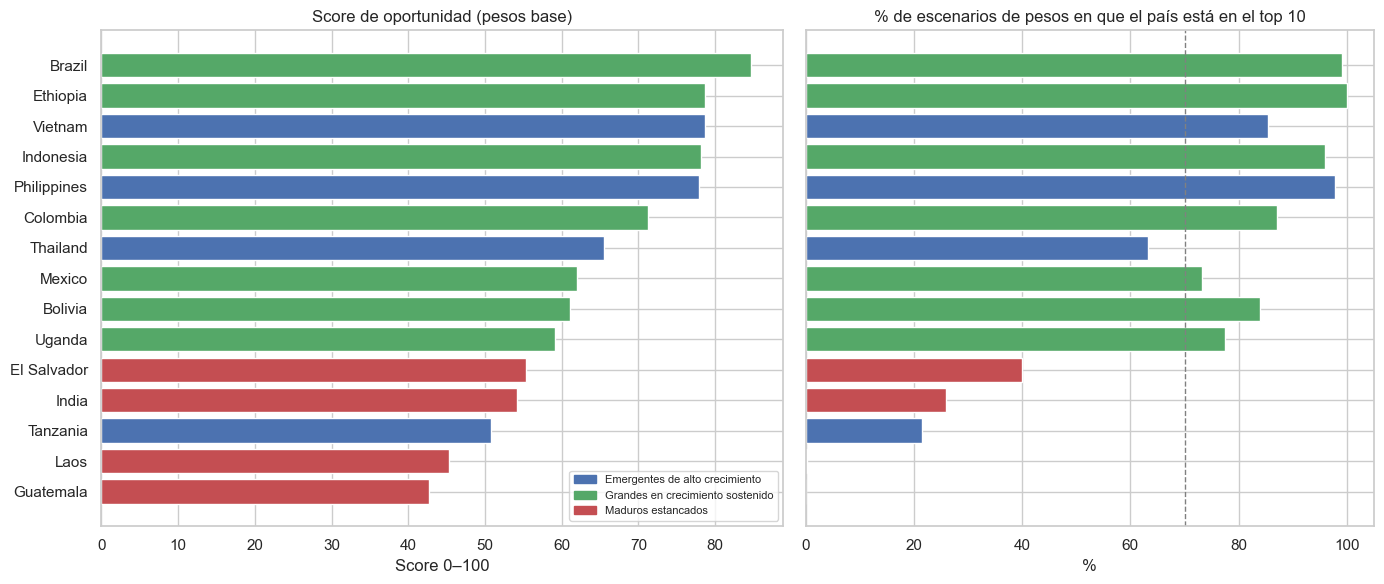

In [6]:
top = ranking.head(15).iloc[::-1]
paleta = dict(zip(sorted(opp.segmento.unique()), sns.color_palette("deep", opp.segmento.nunique())))

fig, ax = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1.2, 1]})
ax[0].barh(top.index, top.score, color=[paleta[s] for s in top.segmento])
ax[0].set(title="Score de oportunidad (pesos base)", xlabel="Score 0–100")
ax[1].barh(top.index, top.freq_top10 * 100, color=[paleta[s] for s in top.segmento])
ax[1].axvline(70, color="grey", ls="--", lw=1)
ax[1].set(title="% de escenarios de pesos en que el país está en el top 10", xlabel="%", yticklabels=[])
segs_top = [sg for sg in paleta if sg in set(top.segmento)]
handles = [plt.Rectangle((0, 0), 1, 1, color=paleta[sg]) for sg in segs_top]
ax[0].legend(handles, segs_top, loc="lower right", fontsize=8)
plt.tight_layout()
save_fig("opp_ranking")
plt.show()

### Proyección vs ritmo reciente
Si un país queda **por encima de la diagonal**, el modelo proyecta crecer más rápido de lo que ha crecido en los últimos 5 años: hay que mirar esas proyecciones con más cautela.

c:\Users\danil\OneDrive\Documentos\GitHub\Prueba_NTT\utils.py:133: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.savefig(FIGS / f"{name}.png", dpi=150, bbox_inches="tight")
c:\Users\danil\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


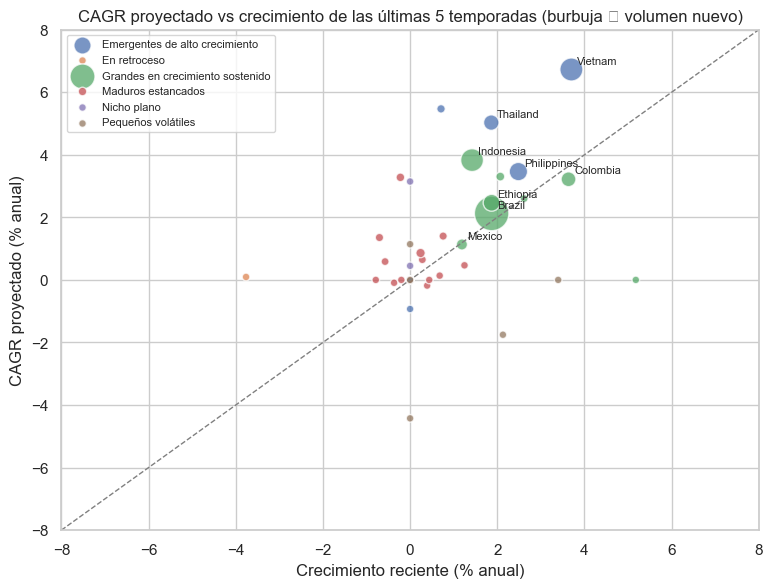

Países con proyección >3 pp/año por encima de su ritmo reciente: 5


,segmento,nivel,cagr_proy,crec_reciente
Vietnam,Emergentes de alto crecimiento,Prioritario,0.067,0.037
Thailand,Emergentes de alto crecimiento,Candidato,0.050,0.019
Nicaragua,Maduros estancados,Bajo,0.033,-0.002
Tanzania,Emergentes de alto crecimiento,Bajo,0.055,0.007
Guyana,Nicho plano,Bajo,0.031,0.000


In [7]:
fig, ax = plt.subplots(figsize=(9, 6.5))
for sg, g in opp.groupby("segmento"):
    ax.scatter(g.crec_reciente * 100, g.cagr_proy * 100, s=30 + g.crec_abs.clip(lower=0) * 4,
               color=paleta[sg], alpha=0.75, label=sg, edgecolor="white")
lim = [-8, 8]
ax.plot(lim, lim, color="grey", ls="--", lw=1)
ax.set(xlim=lim, ylim=lim, title="CAGR proyectado vs crecimiento de las últimas 5 temporadas (burbuja ∝ volumen nuevo)",
       xlabel="Crecimiento reciente (% anual)", ylabel="CAGR proyectado (% anual)")
for c in ranking.head(8).index:
    ax.annotate(c, (opp.loc[c, "crec_reciente"] * 100, opp.loc[c, "cagr_proy"] * 100),
                fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.legend(fontsize=8, loc="upper left")
save_fig("opp_proyeccion_vs_reciente")
plt.show()

opt = opp[opp.alerta_optimismo]
print(f"Países con proyección >3 pp/año por encima de su ritmo reciente: {len(opt)}")
opt.sort_values("crec_abs", ascending=False)[["segmento", "nivel", "cagr_proy", "crec_reciente"]]

## 5. Qué hacer con cada segmento
Cruce del segmento (notebook 03) con el ranking:

In [8]:
resumen = (opp.groupby("segmento")
              .agg(paises=("score", "size"),
                   consumo_2019=("y19", "sum"),
                   crec_abs=("crec_abs", "sum"),
                   prioritarios=("nivel", lambda s: (s == "Prioritario").sum()),
                   nichos=("nivel", lambda s: (s == "Nicho prometedor").sum()),
                   candidatos=("nivel", lambda s: (s == "Candidato").sum()))
              .sort_values("crec_abs", ascending=False))
resumen["% del crecimiento proyectado"] = resumen.crec_abs / resumen.crec_abs.sum() * 100
resumen

,paises,consumo_2019,crec_abs,prioritarios,nichos,candidatos,% del crecimiento proyectado
segmento,,,,,,,
Grandes en crecimiento sostenido,8,"2,125.396",267.768,5,2,0,72.040
Emergentes de alto crecimiento,5,444.900,122.406,2,0,1,32.932
Maduros estancados,19,320.880,10.458,0,0,1,2.814
Nicho plano,10,4.020,0.103,0,0,0,0.028
Pequeños volátiles,6,2.206,0.089,0,0,0,0.024
En retroceso,3,101.460,-29.131,0,0,0,-7.837


## 6. Guardar

In [10]:
ranking.reset_index().rename(columns={"index": "country"}).to_parquet(OUT / "ranking.parquet", index=False)
ranking[cols].to_csv(OUT / "ranking.csv", index_label="country")
print("Guardado: ranking.parquet y ranking.csv")

Guardado: ranking.parquet y ranking.csv


## 7. Conclusiones

1. **Ranking robusto.** El orden base y el mediano de 5,000 combinaciones de pesos casi coinciden (Spearman 1.00). Brasil, Etiopía, Indonesia y Filipinas están en el top 10 en más del 95% de los escenarios.
2. **Siete mercados prioritarios:** Brasil, Etiopía, Vietnam, Indonesia, Filipinas, Colombia y México. Concentran el 82% del consumo y explican +362 M de los +372 M de crecimiento neto proyectado a 2024/25.
3. **Vietnam, con una alerta.** Es el 3.º del ranking y el de mayor crecimiento proyectado (6.7% anual, +61 M), pero casi duplica su ritmo de las últimas 5 temporadas (3.7%). Tailandia (candidato) muestra lo mismo: 5.0% proyectado vs 1.9% reciente. Conviene validar estos dos con información externa antes de comprometer inversión.
4. **Dos nichos prometedores: Bolivia y Uganda.** Crecen de forma pareja y predecible, pero pesan 0.1% y 0.5% del consumo: oportunidades de nicho, no de volumen.
5. **Lo que no entra.** Ningún país de los segmentos *Maduros estancados*, *En retroceso*, *Nicho plano* o *Pequeños volátiles* llega a prioritario. *En retroceso* (Venezuela, Costa Rica, Yemen) resta 29 M al total.
6. **Cómo leerlo.** El ranking mide crecimiento de demanda **doméstica en países productores**. No incluye precios, márgenes, accesibilidad ni logística; esas variables habría que cruzarlas para decidir dónde entrar.

**Siguiente:** presentación que resuma EDA → pronóstico → segmentación → ranking. Los gráficos ya están guardados en `outputs/figs/`.